<a href="https://colab.research.google.com/github/sawantarya232-blip/Deep-Learning/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf # Import TensorFlow, a powerful open-source machine learning library
from tensorflow.keras.models import Sequential # Import Sequential model for building neural networks layer by layer
from tensorflow.keras.layers import Dense # Import Dense layer for fully connected neural network layers
from tensorflow.keras.optimizers import SGD # Import Stochastic Gradient Descent (SGD) optimizer

from sklearn.datasets import load_iris # Import load_iris to get the famous Iris dataset
from sklearn.model_selection import train_test_split # Import train_test_split to divide data into training and testing sets
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling (normalizing data)

import matplotlib.pyplot as plt # Import Matplotlib for plotting graphs

In [ ]:
iris = load_iris() # Load the Iris dataset

X = iris.data # Store the feature data (measurements of the flowers) in X
y = iris.target # Store the target data (species of the flowers) in y

print("Feature Shape:", X.shape) # Print the shape of the feature data (number of samples, number of features)
print("Target Shape:", y.shape)   # Print the shape of the target data (number of samples)
print("Classes:", iris.target_names) # Print the names of the target classes (species)

Feature Shape: (150, 4)
Target Shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, # Features
    y, # Target
    test_size=0.2, # 20% of the data will be used for testing
    random_state=42 # Set a random seed for reproducibility of the split
) # Split the dataset into training and testing sets

In [ ]:
scaler = StandardScaler() # Create an instance of StandardScaler

X_train = scaler.fit_transform(X_train) # Fit the scaler to the training data and transform it (mean=0, variance=1)
X_test = scaler.transform(X_test) # Transform the test data using the *same* scaler fitted on the training data

In [ ]:
def create_model(learning_rate): # Define a function to create our neural network model, taking learning rate as an argument

    model = Sequential() # Initialize a Sequential model (layers will be added one after another)

    # Add the first hidden layer with 10 neurons, ReLU activation, and specify input shape (4 features)
    model.add(Dense(10, activation='relu', input_shape=(4,)))

    # Add a second hidden layer with 8 neurons and ReLU activation
    model.add(Dense(8, activation='relu'))

    # Add the output layer with 3 neurons (for 3 classes) and softmax activation for multi-class classification
    model.add(Dense(3, activation='softmax'))

    optimizer = SGD(learning_rate=learning_rate) # Create an SGD optimizer with the specified learning rate

    model.compile( # Configure the model for training
        optimizer=optimizer, # Use the SGD optimizer
        loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer encoded labels
        metrics=['accuracy'] # Monitor accuracy during training
    )

    return model # Return the compiled model

In [ ]:
learning_rates = [0.001, 0.01, 0.1] # Define a list of learning rates to experiment with

epochs_list = [20, 50, 100] # Define a list of epoch counts to experiment with

results = {} # Dictionary to store training history for each combination of hyperparameters

for lr in learning_rates: # Loop through each learning rate

    for epochs in epochs_list: # Loop through each number of epochs

        print("\n--------------------------------") # Print a separator for readability
        print("Learning Rate:", lr) # Print the current learning rate
        print("Epochs:", epochs) # Print the current number of epochs

        model = create_model(lr) # Create a new model with the current learning rate

        history = model.fit( # Train the model
            X_train, # Training features
            y_train, # Training labels
            epochs=epochs, # Number of training epochs
            validation_split=0.2, # Use 20% of training data for validation
            verbose=0 # Do not print training progress (to keep output clean)
        )

        loss, accuracy = model.evaluate( # Evaluate the trained model on the test data
            X_test, # Test features
            y_test, # Test labels
            verbose=0 # Do not print evaluation progress
        )

        print("Test Accuracy:", accuracy) # Print the accuracy on the test set

        results[(lr, epochs)] = history.history # Store the training history (accuracy, loss) in the results dictionary


--------------------------------
Learning Rate: 0.001
Epochs: 20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.0

--------------------------------
Learning Rate: 0.001
Epochs: 50
Test Accuracy: 0.699999988079071

--------------------------------
Learning Rate: 0.001
Epochs: 100
Test Accuracy: 0.36666667461395264

--------------------------------
Learning Rate: 0.01
Epochs: 20
Test Accuracy: 0.7333333492279053

--------------------------------
Learning Rate: 0.01
Epochs: 50
Test Accuracy: 0.6666666865348816

--------------------------------
Learning Rate: 0.01
Epochs: 100
Test Accuracy: 0.8999999761581421

--------------------------------
Learning Rate: 0.1
Epochs: 20
Test Accuracy: 0.9333333373069763

--------------------------------
Learning Rate: 0.1
Epochs: 50
Test Accuracy: 1.0

--------------------------------
Learning Rate: 0.1
Epochs: 100
Test Accuracy: 0.9666666388511658


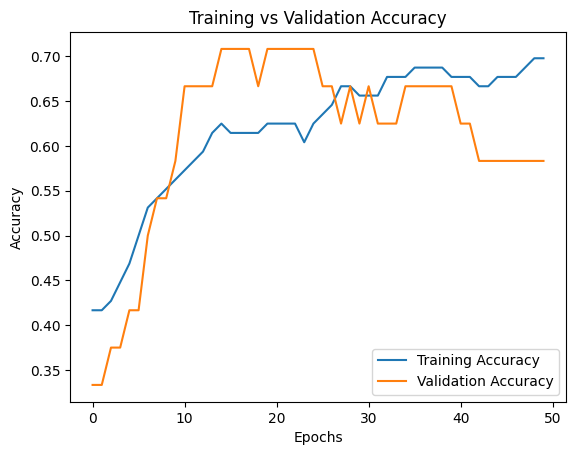

In [ ]:
history = results[(0.01, 50)] # Select the training history for learning rate 0.01 and 50 epochs

plt.plot(history['accuracy'], label="Training Accuracy") # Plot training accuracy over epochs
plt.plot(history['val_accuracy'], label="Validation Accuracy") # Plot validation accuracy over epochs

plt.xlabel("Epochs") # Label for the x-axis
plt.ylabel("Accuracy") # Label for the y-axis
plt.title("Training vs Validation Accuracy") # Title of the plot

plt.legend() # Display the legend to differentiate lines

plt.show() # Show the plot

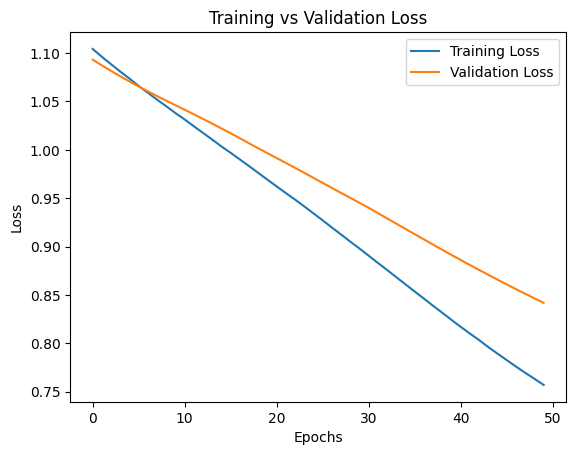

In [ ]:
plt.plot(history['loss'], label="Training Loss") # Plot training loss over epochs
plt.plot(history['val_loss'], label="Validation Loss") # Plot validation loss over epochs

plt.xlabel("Epochs") # Label for the x-axis
plt.ylabel("Loss") # Label for the y-axis
plt.title("Training vs Validation Loss") # Title of the plot

plt.legend() # Display the legend to differentiate lines

plt.show() # Show the plot